# Options Volatility Modeling
## Comparing Black-Scholes and SABR Models on Real Market Data

## 1. Introduction
In this notebook we explore the limitations of the Black-Scholes model 
and demonstrate how the SABR stochastic volatility model better captures 
real market behavior. We use real SPY options data to extract implied 
volatilities, visualize the volatility smile, and compare model fits 
quantitatively using RMSE.

## 2. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import brentq, minimize
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore') #suppress all warning messages

print("All libraries imported successfully")

All libraries imported successfully


## 3. Fetching SPY Options Data
We fetch real options data for SPY (S&P 500 ETF) using yfinance. 
SPY is ideal because it is heavily traded, meaning liquid options 
with reliable prices.

### Why SPY?
SPY (S&P 500 ETF) is one of the most heavily traded securities in the 
world, making it ideal for options analysis for several reasons:

- **Tight bid-ask spreads:** High trading volume creates competition 
  between buyers and sellers, pushing bid and ask prices very close 
  together (e.g., $5.00/$5.02 vs $5.00/$5.50 for illiquid options)
- **Reliable mid prices:** Tight spreads mean our mid price 
  (average of bid and ask) accurately reflects true market value
- **Clean implied volatilities:** Reliable mid prices translate 
  directly into accurate implied volatility calculations
- **Institutional participation:** Nearly every hedge fund and 
  institutional investor uses SPY options for hedging, ensuring 
  continuous and active trading across all strike prices

Poor liquidity → wide spreads → unreliable mid prices → 
corrupted implied volatilities → noisy volatility smile.
SPY avoids all of these problems.

Look at all available methods and attributes  
`dir(yf)`  
Full documentaion of a particular method  
`help(yf.Ticker)`  
Available info for a specific ticker object  
`spy = yf.Ticker("SPY")`   
`dir(spy)`

In [2]:
# fetch the SPY options data
spy = yf.Ticker("SPY")

#spy.info            # general info about the stock
#spy.history()       # historical price data
#spy.options         # available expiry dates
#spy.option_chain()  # options data for a specific expiry

In [3]:
# list of all available methods and attributes
#dir(spy)

# full documentation
#help(spy.history)

In [4]:
# Get the current stock price
current_price = spy.history(period = "1d")['Close'].iloc[-1]
print(f'Current SPY price: {current_price:.2f}')

# See available expiry dates
expiry_dates = spy.options
print(f'\nAvailable expiry dates:')
for i, date in enumerate(expiry_dates[:10]): #show first 10
    print(f'{i+1}:{date}')

Current SPY price: 669.03

Available expiry dates:
1:2026-03-16
2:2026-03-17
3:2026-03-18
4:2026-03-19
5:2026-03-20
6:2026-03-23
7:2026-03-24
8:2026-03-25
9:2026-03-26
10:2026-03-27


In [5]:
#get all expiry dates
for i, date in enumerate(expiry_dates):
    print(f'{i+1}:{date}')

1:2026-03-16
2:2026-03-17
3:2026-03-18
4:2026-03-19
5:2026-03-20
6:2026-03-23
7:2026-03-24
8:2026-03-25
9:2026-03-26
10:2026-03-27
11:2026-03-31
12:2026-04-02
13:2026-04-10
14:2026-04-17
15:2026-04-24
16:2026-04-30
17:2026-05-01
18:2026-05-15
19:2026-05-29
20:2026-06-18
21:2026-06-30
22:2026-07-17
23:2026-07-31
24:2026-08-21
25:2026-08-31
26:2026-09-18
27:2026-09-30
28:2026-12-18
29:2026-12-31
30:2027-01-15
31:2027-03-19
32:2027-06-17
33:2027-12-17
34:2028-01-21
35:2028-06-16
36:2028-12-15


### Why We Choose a 30-60 Day Expiry Date

When selecting an options expiry date for volatility analysis, the 
time to expiry (also called DTE - Days to Expiry) matters significantly.

**Too short (< 30 days):**
- Options near expiry are dominated by gamma risk
- Implied volatilities become unstable and noisy
- Prices change very rapidly and erratically as expiry approaches,
  making smile fitting unreliable

**Too long (> 60 days):**
- Lower trading volume and wider bid-ask spreads i.e. fewer people
  are trading them
- Prices are less reliable due to lower liquidity
- Volatility smile becomes flatter and less interesting to analyze

**Sweet spot (30-60 days):**
- Enough time value to produce a meaningful volatility smile
- High liquidity means reliable, clean prices
- Stable implied volatilities suitable for model calibration

We choose **April 17, 2026** (46 days out from today, March 02, 2026) because:
- Falls in the middle of our 30-60 day target range
- It is the **third Friday of April** - a standard monthly expiry date
- Monthly expiries consistently attract the highest trading volume
  because institutional hedging strategies are structured around 
  monthly cycles, meaning tighter bid-ask spreads and more 
  reliable prices

In [6]:
# Fetch options chain for selected expiry date
expiry = "2026-04-17"
opt_chain = spy.option_chain(expiry)

# option chain returns two dataframes
calls = opt_chain.calls 
puts = opt_chain.puts

print(f'Number of call contracts: {len(calls)}')
print(f'Number of put contracts: {len(puts)}')
print(f'\nCall columns: {calls.columns.tolist()}')
print(f"\nFirst few rows of calls:")
calls.head()

Number of call contracts: 216
Number of put contracts: 185

Call columns: ['contractSymbol', 'lastTradeDate', 'strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'inTheMoney', 'contractSize', 'currency']

First few rows of calls:


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260417C00300000,2026-03-16 14:43:36+00:00,300.0,368.44,367.98,370.79,-27.700012,-6.99248,1.0,1,1.093755,True,REGULAR,USD
1,SPY260417C00325000,2026-03-02 14:31:44+00:00,325.0,355.86,342.99,345.79,0.000000,0.00000,5.0,5,0.993652,True,REGULAR,USD
2,SPY260417C00350000,2026-03-06 15:35:50+00:00,350.0,325.00,318.00,320.81,0.000000,0.00000,2.0,3,0.903810,True,REGULAR,USD
3,SPY260417C00355000,2026-03-05 19:51:46+00:00,355.0,323.11,312.99,315.81,0.000000,0.00000,NaN,903,0.883790,True,REGULAR,USD
4,SPY260417C00360000,2026-02-27 17:45:33+00:00,360.0,324.60,308.00,310.81,0.000000,0.00000,30.0,89,0.867677,True,REGULAR,USD


### Understanding the Options Chain Data

Each row represents one options contract. Here is what each column means:

- **contractSymbol:** Unique identifier for the contract (e.g., SPY260417C00300000 = SPY, expiry 2026-04-17, Call, strike $300)
- **lastTradeDate:** When this contract was last traded
- **strike:** The strike price of the option; predetermined price at which an options contract holder can buy or sell the option
- **lastPrice:** Price of the last trade, we avoid using this because it may be stale (traded hours or days ago)
- **bid:** Highest price a buyer is willing to pay right now
- **ask:** Lowest price a seller is willing to accept right now
- **mid price:** Average of bid and ask, this is what we will use as our market price because it reflects current market consensus
- **volume:** Number of contracts traded today
- **openInterest:** Total number of outstanding contracts; key liquidity indicator
- **impliedVolatility:** yfinance's own IV estimate; we will calculate our own more carefully
- **inTheMoney:** Whether the option has intrinsic value currently; meaning it would be pofitable to exercise immediately(asset price is above or below the strike price for call or put option resp.)

### Cleaning the Options Chain Data

We filter the raw options data to keep only reliable, liquid contracts.
Filtering criteria:
1. Remove contracts with zero bid price i.e. not actively quoted
2. Remove contracts with very low open interest (< 100) i.e. illiquid
3. Remove contracts with very low volume i.e. not actively traded
4. Focus on near-the-money strikes (i.e. strike price close to current market price); far OTM (Out-of-the-Money i.e. strike price is unfavorable compared to current market price) options are unreliable
5. Calculate mid price as our market price
6. Only keep the columns that are of interest to us i.e. `strike, bid, ask, midPrice, volume, openInterest, impliedVoltality`

In [7]:
def clean_options_data(df, current_price, otm_filter = 0.3):
    '''
    Cleans and filters options data
    
    Parameters:
    df: raw options dataframe (calls or puts)
    current_price: current stock price of SPY
    otm_filter: strick price is within this many % of current price. e.g. 0.3 means 0.3x100 i.e. 30%

    Returns: cleaned and filtered dataframe and only with columns of use
    '''

    df = df.copy() # creates a new independent copy of a pandas dataframe and assigns it back to a variable df

    # remove contracts with zero bid price
    df = df[df['bid'] > 0]

    # remove contracts with low open interest (< 100)
    df = df[df['openInterest'] > 100]

    # remove contracts with very low volume
    df['volume'] = df['volume'].fillna(0)   # replace NaN with zero
    df = df[df['volume'] > 10]

    # focus on strike price within otm_filter% of the current price
    df = df[df['strike'] >= current_price * (1 - otm_filter)]
    df = df[df['strike'] <= current_price * (1 + otm_filter)]
    
    # calculate mid-pice
    df['midPrice'] = (df['bid'] + df['ask'])/2

    # keep only relevent columns
    df = df[['strike', 'bid', 'ask', 'midPrice', 'volume', 'openInterest', 'impliedVolatility']]

    return df.reset_index(drop=True) # discards old index and uses default integer index (0, 1, 2, ..)

# Clean calls and puts dataframes
calls_clean = clean_options_data(calls, current_price)
puts_clean = clean_options_data(puts, current_price)

print(f'Calls before cleaning: {len(calls)} and after: {len(calls_clean)}')
print(f'Puts before cleaning: {len(puts)} and after: {len(puts_clean)}')
print(f'\nCleaned calls:')
calls_clean.head(10)

Calls before cleaning: 216 and after: 101
Puts before cleaning: 185 and after: 99

Cleaned calls:


,strike,bid,ask,midPrice,volume,openInterest,impliedVolatility
0,600.0,71.18,73.99,72.585,86.0,173,0.344611
1,610.0,61.93,64.74,63.335,102.0,465,0.323829
2,620.0,53.33,55.26,54.295,103.0,927,0.295692
3,630.0,44.71,46.46,45.585,15.0,355,0.276710
4,635.0,40.54,42.18,41.360,30.0,1227,0.267341
5,640.0,36.27,38.20,37.235,16.0,1295,0.261116
6,645.0,32.37,34.07,33.220,123.0,1966,0.250954
7,650.0,29.25,29.47,29.360,143.0,4197,0.232735
8,652.0,27.24,28.06,27.650,100.0,229,0.230949
9,655.0,25.51,25.78,25.645,82.0,3049,0.225380


### Visualizing Cleaned Options Data

Before extracting implied volatilities, let's visualize the distribution 
of strikes and mid prices to confirm our cleaning produced sensible data.

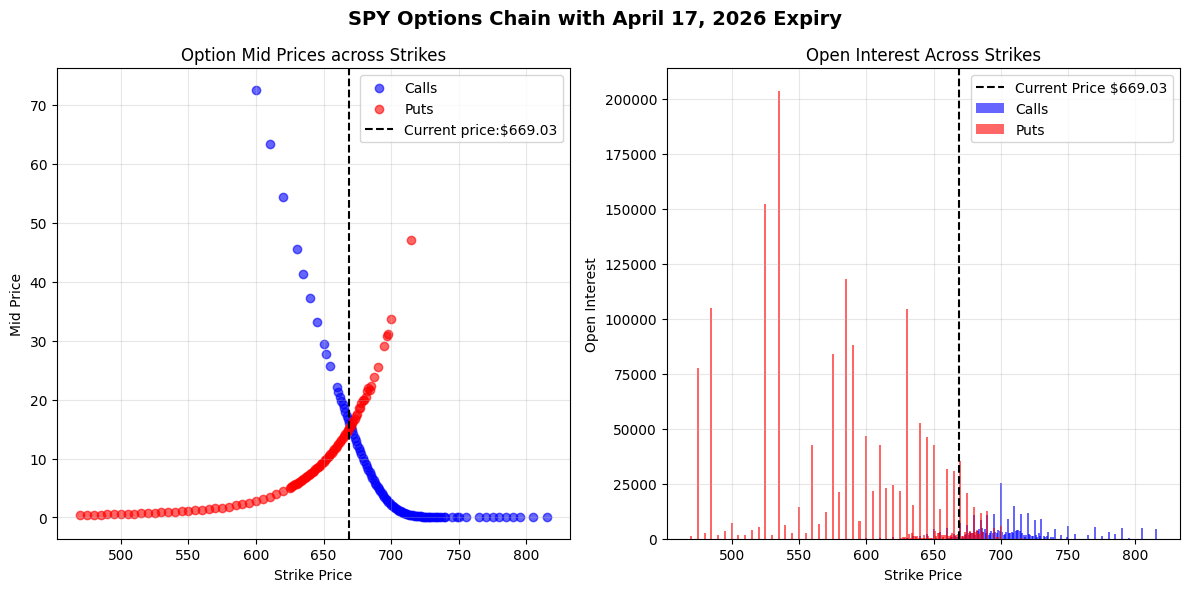

In [8]:
fig, axs = plt.subplots(1, 2, figsize = (12, 6)) # fig: entire figure/window; axs: individual subplots

axs[0].scatter(calls_clean['strike'], calls_clean['midPrice'], color='blue', alpha=0.6, label='Calls')
axs[0].scatter(puts_clean['strike'], puts_clean['midPrice'], color='red', alpha=0.6, label='Puts')
axs[0].axvline(x=current_price, color='black', label=f'Current price:${current_price:.2f}', linestyle='--')
axs[0].set_xlabel('Strike Price')
axs[0].set_ylabel('Mid Price')
axs[0].set_title('Option Mid Prices across Strikes')
axs[0].legend()
axs[0].grid(True, alpha=0.3)

axs[1].bar(calls_clean['strike'], calls_clean['openInterest'], 
            color='blue', alpha=0.6, label='Calls', width=1.5)
axs[1].bar(puts_clean['strike'], puts_clean['openInterest'], 
            color='red', alpha=0.6, label='Puts', width=1.5)
axs[1].axvline(x=current_price, color='black', linestyle='--', 
                label=f'Current Price ${current_price:.2f}')
axs[1].set_xlabel('Strike Price')
axs[1].set_ylabel('Open Interest')
axs[1].set_title('Open Interest Across Strikes')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

plt.suptitle('SPY Options Chain with April 17, 2026 Expiry', fontsize=14, fontweight='bold')

plt.tight_layout() # Adjust layout to prevent overlapping
plt.show()

### Observations from Cleaned Options Data

**Left Plot: Mid Price vs. Strike Price:**
- Call prices decrease as strike increases; a call at $800 is worth 
  less than one at $600 since $800 is far above current price
- Put prices increase as strike increases; a put at $650 is worth 
  more than one at $500 since $650 is closer to current price
- The two curves cross at current price ($669), this is called 
  **put-call parity** and confirms our data is internally consistent

**Right Plot: Open Interest vs. Strike Price:**
- Open interest is heavily concentrated in puts below current price
- This reflects the "fear trade", institutional investors massively 
  buy downside puts as portfolio insurance against market crashes
- Nobody hedges against SPY going up, but everyone hedges against 
  it going down
- This asymmetry is our first evidence that markets behave 
  differently on the downside vs upside, something Black-Scholes 
  cannot capture with its constant volatility assumption
- This pattern directly motivates why we need the SABR model